In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from speedtest import distance
from torch.ao.nn.quantized.functional import threshold

insurance_data = pd.read_csv('insurance.csv')
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


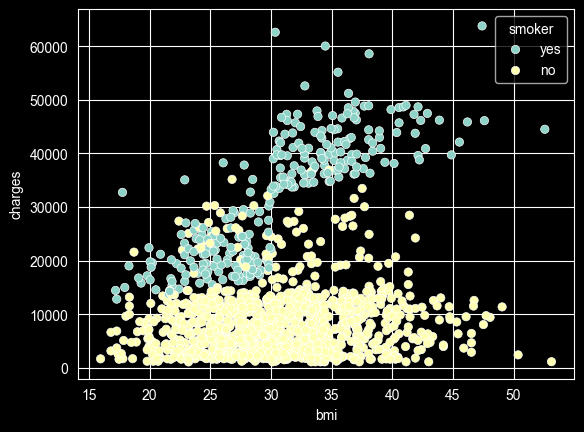

In [2]:
sns.scatterplot(data=insurance_data, x='bmi', y='charges',hue='smoker')
plt.show()

In [3]:
x = insurance_data.drop(columns=['charges','region'])
y = insurance_data['charges']

x['sex'] = x['sex'].map({'male':0, 'female':1})
x['smoker'] = x['smoker'].map({'yes':1, 'no':0})



In [4]:
x.head(100)

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0
...,...,...,...,...,...
95,28,1,37.620,1,0
96,54,1,30.800,3,0
97,55,0,38.280,0,0
98,56,0,19.950,0,1


In [5]:
#train_test_split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)



In [6]:
#Train Model
from sklearn.linear_model import LinearRegression, LassoCV

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [7]:
#Predict Values

y_pred = model.predict(x_test)

In [8]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [9]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [10]:
#Evaluate

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.7811302113434095


In [11]:
x_test.shape

(268, 5)

In [12]:
#Adjusted r2 value

n = x_test.shape[0]
p = x_test.shape[1]

adjusted_r2 = 1 - ((1-r2)* (n-1)/(n-p-1))
print("adjusted_r2:", adjusted_r2)

adjusted_r2: 0.7769533069797342


In [13]:
#One Hot Encoding
x = insurance_data.drop(columns=['charges'])
y = insurance_data['charges']

x = pd.get_dummies(x, columns=['region'], drop_first=False, dtype=int)

x['sex'] = x['sex'].map({'male':0, 'female':1})
x['smoker'] = x['smoker'].map({'yes':1, 'no':0})

In [14]:
x.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,0,1
1,18,0,33.770,1,0,0,0,1,0
2,28,0,33.000,3,0,0,0,1,0
3,33,0,22.705,0,0,0,1,0,0
4,32,0,28.880,0,0,0,1,0,0


In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

re = r2_score(y_test, y_pred)
print("R-squared:", re)


R-squared: 0.7835929767120723


In [16]:
#Interaction Features
x = insurance_data.drop(columns=['charges'])
y = insurance_data['charges']

x = pd.get_dummies(x, columns=['region'], drop_first=True, dtype=int)

x['sex'] = x['sex'].map({'male':0, 'female':1})
x['smoker'] = x['smoker'].map({'yes':1, 'no':0})

x["age_smoker"] = x['age'] * x["smoker"]
x["bmi_smoker"] = x['bmi'] * x["smoker"]

x.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

re = r2_score(y_test, y_pred)
print("R-squared:", re)

R-squared: 0.865231697953168


In [18]:
#Underfitting and Overfitting
#r2 for training value is low and also low for testing data is one example of - underfit
# if r2 training is high but r2 is low for testing then it is maybe overfit case

y_train_pred = model.predict(x_train)
r2_train = r2_score(y_train, y_train_pred)

print("Training data r2:", r2_train)
print("test data r2:",r2)


Training data r2: 0.8340713711218875
test data r2: 0.7811302113434095


MSE: 20922599.87103596
MSE: 20921803.698431376
MSE: 20914832.63508914
MSE: 20908106.779954515
MSE: 20890881.000633497
MSE: 20872844.794796683
MSE: 20877828.53237883
MSE: 20937537.133939773
MSE: 21046489.29389078
MSE: 21196929.8696089
MSE: 22423172.686023254


<Axes: >

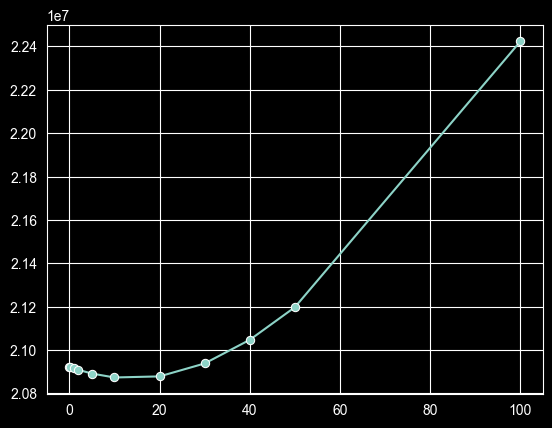

In [19]:
#Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

alphas = [0.001,0.1,1,2,5,10,20,30,40,50,100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(x_train, y_train)
    y_pred = lasso_model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    print("MSE:", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker='o')

In [20]:
#Better way to find alphas then previous graph
from sklearn.linear_model import LassoCV

a = [0.001,0.1,1,2,5,10,20,30,40,50,100]

lasso_cv_model = LassoCV(alphas=a, cv=5, max_iter=1000, random_state=42)
lasso_cv_model.fit(x_train, y_train)

print("Best alpha:", lasso_cv_model.alpha_)

y_pred = lasso_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

Best alpha: 0.001
MSE: 22423172.686023254


In [21]:
#LogisticRegression
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

heart_df = pd.read_csv('1-heart.csv')
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [22]:

X = heart_df.drop(columns=['target'])
y = heart_df['target']

y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [23]:
#Train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")

Accuracy: 88.52459016393442 %
Precision: 87.87878787878788 %


In [25]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3


In [26]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[-1.35679832,  0.72250438,  0.00809909, ...,  0.95390513,
        -0.68970073, -0.50904773],
       [ 0.38508599,  0.72250438, -0.97189094, ...,  0.95390513,
        -0.68970073,  1.17848036],
       [-0.92132724,  0.72250438,  0.98808912, ..., -0.69498803,
        -0.68970073, -0.50904773],
       ...,
       [ 1.58263146,  0.72250438,  1.96807914, ..., -0.69498803,
         0.32186034, -0.50904773],
       [-0.92132724,  0.72250438, -0.97189094, ...,  0.95390513,
        -0.68970073,  1.17848036],
       [ 0.92942484, -1.38407465,  0.00809909, ...,  0.95390513,
         1.33342142, -0.50904773]], shape=(242, 13))

In [27]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")

Accuracy: 85.24590163934425 %
Precision: 87.09677419354838 %


In [28]:
# Evaluation Metrics

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:",cm)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")
print("Recall:", recall_score(y_test, y_pred)*100,"%")
print("F1:", f1_score(y_test, y_pred)*100,"%")

Confusion Matrix: [[25  4]
 [ 5 27]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

Accuracy: 85.24590163934425 %
Precision: 87.09677419354838 %
Recall: 84.375 %
F1: 85.71428571428571 %


In [29]:
#Navie Bayes Algorithm

import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

heart_df = pd.read_csv('1-heart.csv')

x = heart_df.drop(columns=['target'])
y = heart_df['target']

y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

x_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3


In [31]:
gnb_model = GaussianNB()
gnb_model.fit(x_train, y_train)

GaussianNB()

In [32]:
y_pred = gnb_model.predict(x_test)

In [33]:
#Evaluate

print("Recall:", recall_score(y_test, y_pred)*100,"%")
print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")
print("F1:", f1_score(y_test, y_pred)*100,"%")

Recall: 84.375 %
Accuracy: 86.88524590163934 %
Precision: 90.0 %
F1: 87.09677419354838 %


In [34]:
#KNN - k Nearest Neighbours Algorithm

from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

heart_df = pd.read_csv('1-heart.csv')

x = heart_df.drop(columns=['target'])
y = heart_df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

knn_classifier = KNeighborsClassifier()
knn_classifier.fit(x_train_scaled, y_train)

y_pred = knn_classifier.predict(x_test_scaled)

print("Recall:", recall_score(y_test, y_pred)*100,"%")
print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")

Recall: 87.5 %
Accuracy: 90.1639344262295 %
Precision: 93.33333333333333 %


In [35]:
#k=3
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(x_train_scaled, y_train)

y_pred = knn_classifier.predict(x_test_scaled)

print("Recall:", recall_score(y_test, y_pred)*100,"%")
print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")

Recall: 78.125 %
Accuracy: 85.24590163934425 %
Precision: 92.5925925925926 %


In [36]:
#k=7 - Best for still now among k3,9,5
knn_classifier = KNeighborsClassifier(n_neighbors=7)
knn_classifier.fit(x_train_scaled, y_train)

y_pred = knn_classifier.predict(x_test_scaled)

print("Recall:", recall_score(y_test, y_pred)*100,"%")
print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")

Recall: 90.625 %
Accuracy: 91.80327868852459 %
Precision: 93.54838709677419 %


In [37]:
# Cross Validation For hyperparam tuning using GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

classifier = KNeighborsClassifier()
param_grid = {"n_neighbors": [3,5,7,9]}

classifierCV  = GridSearchCV(
    classifier,
    param_grid,
    cv=5
)

classifierCV.fit(x_train_scaled, y_train)

y_pred = classifierCV.predict(x_test_scaled)

print("Recall:", recall_score(y_test, y_pred)*100,"%")
print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")

#result

res = pd.DataFrame(classifierCV.cv_results_)
print(res[["param_n_neighbors","mean_test_score"]])
print(classifierCV.best_params_)

Recall: 87.5 %
Accuracy: 90.1639344262295 %
Precision: 93.33333333333333 %
   param_n_neighbors  mean_test_score
0                  3         0.805782
1                  5         0.814116
2                  7         0.801616
3                  9         0.801786
{'n_neighbors': 5}


In [38]:
#Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {"knn__n_neighbors": [3,5,7,9]}

classifierCV = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="recall"
)

classifierCV.fit(x_train, y_train)

y_pred = classifierCV.predict(x_test)


print("recall:", recall_score(y_test, y_pred)*100,"%")
print("Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
print("Precision:", precision_score(y_test, y_pred)*100,"%")

print(classifierCV.best_params_)

recall: 90.625 %
Accuracy: 91.80327868852459 %
Precision: 93.54838709677419 %
{'knn__n_neighbors': 7}


In [39]:
#Linear Regression scratch implementation

import numpy as np

#Linear Regression

from sklearn.linear_model import LinearRegression

class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.bais = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def fit(self, X, y): #X_train ,y_train
        m, n = X.shape # (number of sample, number of features)
#Step 1
        self.bais = 0
        self.weights = np.zeros(n) # [0,0,0.....,0]

        #Gradient Descent
        for i in range(self.n_iter):
    #Step 2
            y_pred = self.bais + np.dot(X, self.weights)
    #Step 3
            db = (1/m) * np.sum(y_pred - y)
            dw = (1/m) * np.dot(X.T, y_pred - y)
    #Step 4 - convergence theorem - params update
            self.bais -= self.lr * dw
            self.weights += self.lr * dw


    def predict(self, X):
        y_pred = self.bais + np.dot(X, self.weights)
        return y_pred


In [40]:
X = np.array([[1],[2],[3],[4],[5]])
y = np.array([2,4,6,8,10])

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print(y_pred)

print(model.bais)
print(model.weights)

[ 0.00000000e+00 -7.29605637e+33 -1.45921127e+34 -2.18881691e+34
 -2.91842255e+34]
[7.29605637e+33]
[-7.29605637e+33]


In [41]:
# Linear Regression with OLS - Ordinary Least Squares

class LinearRegressionOLS:
    def __init__(self):
        self.bias = None
        self.weights = None

    def fit(self, X, y):
        m, n = X.shape

        X_updated_B = np.c_[np.ones((m,1)), X]

        # normal equation
        # theta = np.dot( np.linalg.inv(np.dot((X_updated_B.T, X_updated_B)), np.dot(X_updated_B.T, y))
        #OR another way to write above code
        theta = np.linalg.inv(X_updated_B.T @ X_updated_B) @ X_updated_B.T @ y

        self.bias = theta[0]
        self.weights = theta[1:]

    def predict(self, X):
        y_pred = self.bias + np.dot(X, self.weights)
        return y_pred

X = np.array([[1],[2],[3],[4],[5]])
y = np.array([2,4,6,8,10])

model = LinearRegressionOLS()
model.fit(X, y)

y_pred = model.predict(X)

print(y_pred)

print(model.bias)
print(model.weights)

[ 2.  4.  6.  8. 10.]
5.662137425588298e-15
[2.]


In [42]:
#Logistic Regression

class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.bais = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    def _sigmoid(self,z):
        return (1/(1 + np.exp(-z)))

    def fit(self, X, y):
        m, n = X.shape

        self.bais = 0
        self.weights = np.zeros(n)

        for i in range(self.n_iter):
            z = self.bais + np.dot(X, self.weights)
            y_pred = self._sigmoid(z)

            db = (1/m) * (y_pred - y)
            dw = (1/m) * np.dot(X.T,( y_pred - y))

            self.bais -= self.lr * db
            self.weights += self.lr * dw

    def get_probabilities(self,X):
        z = self.bais + np.dot(X, self.weights)
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        probabilities = self.get_probabilities(X)
        probabilities >= threshold
        y_pred_bool = probabilities >= threshold
        return y_pred_bool.astype(int)

X = np.array([[1,2],[2,3],[3,4],[4,5],[5,6]])
y = np.array([0,0,0,1,1])

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X)
print(y_pred)
print(model.get_probabilities(X))

[0 0 0 0 0]
[4.71751217e-27 4.98637150e-44 5.24328156e-61 4.06426356e-77
 4.26189195e-94]


[0 1]


<Axes: xlabel='x1', ylabel='x2'>

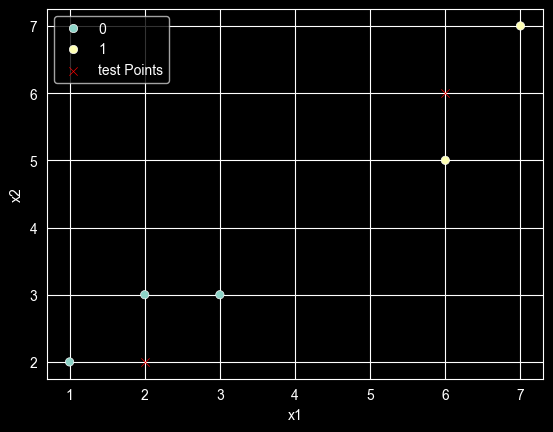

In [43]:
#kNN Classifier Implementation from scratch for binary classification

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum(np.square(x1 - x2)**2))

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        distance = [self._euclidean_dist(x, x_train) for x_train in self.X_train]

        knn_indices = np.argsort(distance)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]

        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class

    def predict(self, X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)


# Data
X_train = np.array([
    [1,2],
    [2,3],
    [3,3],
    [6,5],
    [7,7]
])

y_train = np.array([0,0,0,1,1])
X_test = np.array([
    [2,2],
    [6,6]
])

model = KNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

#Visulize

X_train_df = pd.DataFrame(X_train, columns=["x1","x2"])
X_train_df["label"] = y_train

sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label"
)

X_test_df = pd.DataFrame(X_test, columns=["x1","x2"])

sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="red",
    marker="x",
    label="test Points"
)

In [44]:
# Implement KNN Regressor from Scratch

class KNNRegressor:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum(np.square(x1 - x2), axis=1))

    def _predict_one(self, x):
        # Compute distances
        distances = self._euclidean_distance(self.X_train, x)

        #Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get k nearest target values
        k_nearest_values = self.y_train[k_indices]

        # Return mean of neighbors
        return np.mean(k_nearest_values)

    def predict(self, X):
        X = np.array(X)
        predictions = [self._predict_one(x) for x in X]
        return np.array(predictions)

# Training data

X_train = np.array([[1],[2],[3],[4],[5]])
y_train = np.array([2,4,6,8,10])

# Test data
X_test = np.array([[1.5],[3.5],[6]])

# Create and train model
knn = KNNRegressor(k=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)
print("Predictions: ",y_pred)




Predictions:  [4. 6. 8.]


In [45]:
#Decision Tree classifier

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [46]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [47]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [48]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [49]:
features = ['pclass','sex','fare','embarked','age']
target = ['survived']
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [50]:
# missing data filling
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy='median')
titanic[['age']] = imp_median.fit_transform(titanic[['age']])

imp_freq = SimpleImputer(strategy='most_frequent')
titanic[['embarked']] = imp_freq.fit_transform(titanic[['embarked']])


titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [51]:
# encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [52]:
# Train test split
from sklearn.model_selection import train_test_split

X = titanic[features]
y = titanic[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [53]:
# Decision Tree Model - no pruning

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [54]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred)*100)

Accuracy:  76.53631284916202


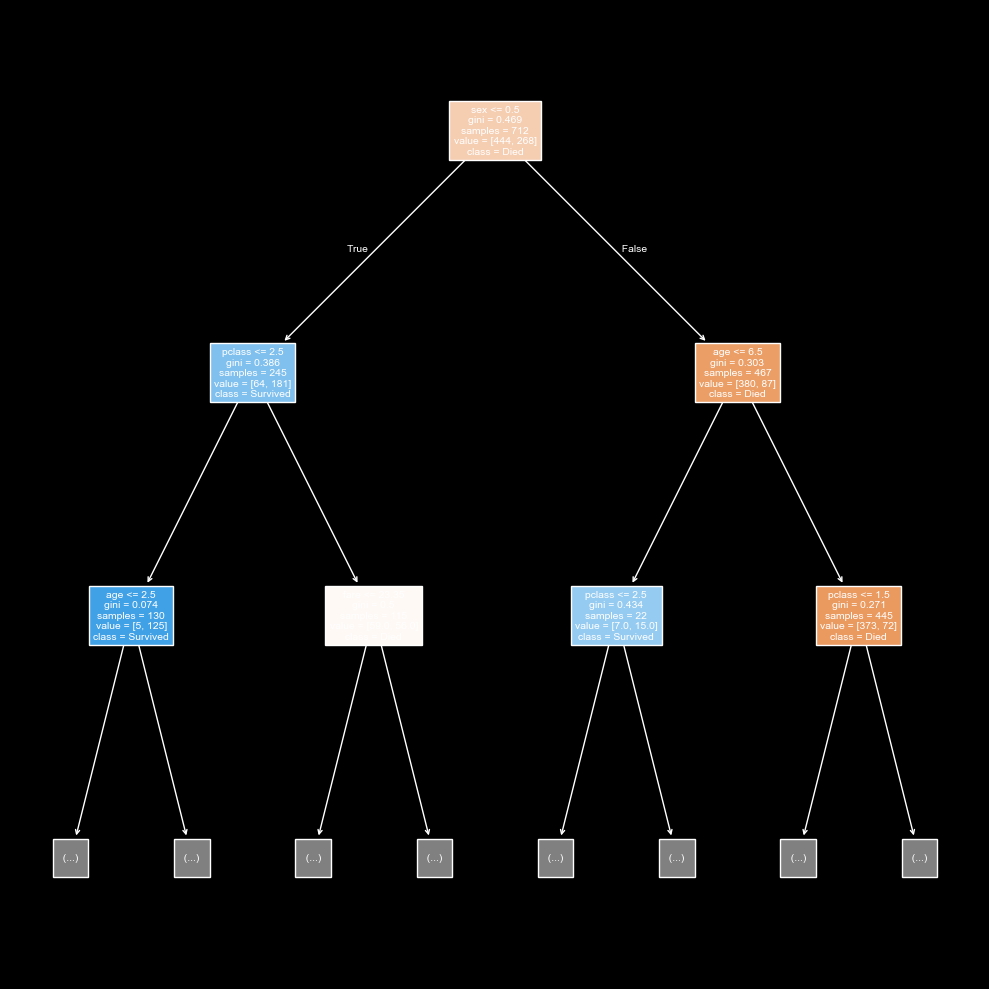

In [55]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2,
)

plt.tight_layout()
plt.show()

In [56]:
# Decision Tree with Pre-Pruning

max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth {depth}, accuracy={acc}")

for depth 2, accuracy=0.7653631284916201
for depth 3, accuracy=0.7988826815642458
for depth 4, accuracy=0.7988826815642458
for depth 5, accuracy=0.7988826815642458
for depth 6, accuracy=0.7988826815642458
for depth 7, accuracy=0.7877094972067039
for depth 8, accuracy=0.7932960893854749
for depth 9, accuracy=0.7877094972067039
for depth 10, accuracy=0.8100558659217877


In [57]:
min_sample_splits = [5,10,15,20,25,30]

for split in min_sample_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for sample split {split}, accuracy={acc}")

for sample split 5, accuracy=0.7988826815642458
for sample split 10, accuracy=0.7988826815642458
for sample split 15, accuracy=0.7988826815642458
for sample split 20, accuracy=0.7988826815642458
for sample split 25, accuracy=0.7932960893854749
for sample split 30, accuracy=0.7932960893854749


In [58]:
# Decision Tree with Post-Pruning

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [59]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [60]:
# Train our models for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    trees.append((model, alpha))


best_acc = 0
best_acc = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

best_acc

0.8379888268156425

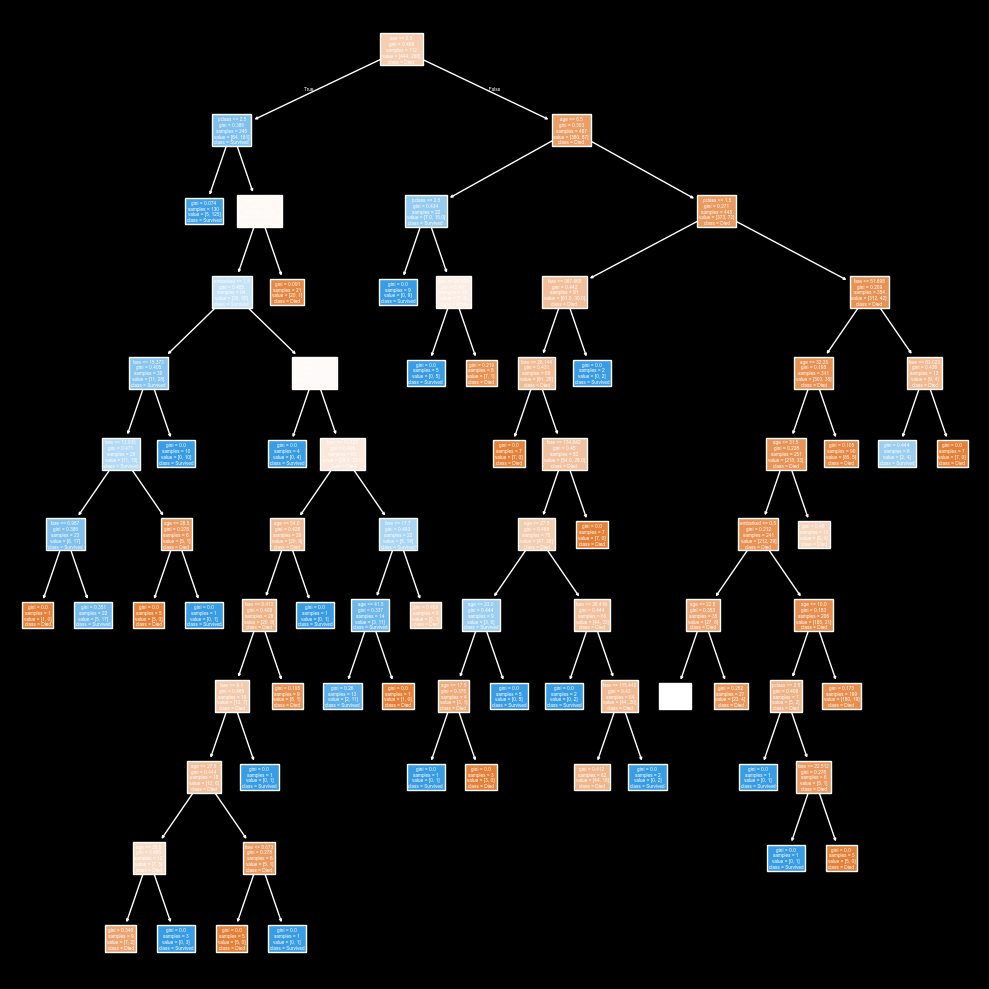

In [61]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

plt.figure(figsize=(10,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [62]:
print(best_model.score(X_test, y_test))

0.8379888268156425


In [63]:
# Decision Tree Regressor

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

df = load_diabetes(as_frame=True).frame
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [64]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [66]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE train: ", mean_squared_error(y_train, y_pred_train)*100)
print("MSE test: ", mean_squared_error(y_test, y_pred_test)*100)

print("r^2 train: ", r2_score(y_train, y_pred_train)*100)
print("r^2 test: ", r2_score(y_test, y_pred_test)*100)

MSE train:  0.0
MSE test:  480039.3258426966
r^2 train:  100.0
r^2 test:  9.39494589276345


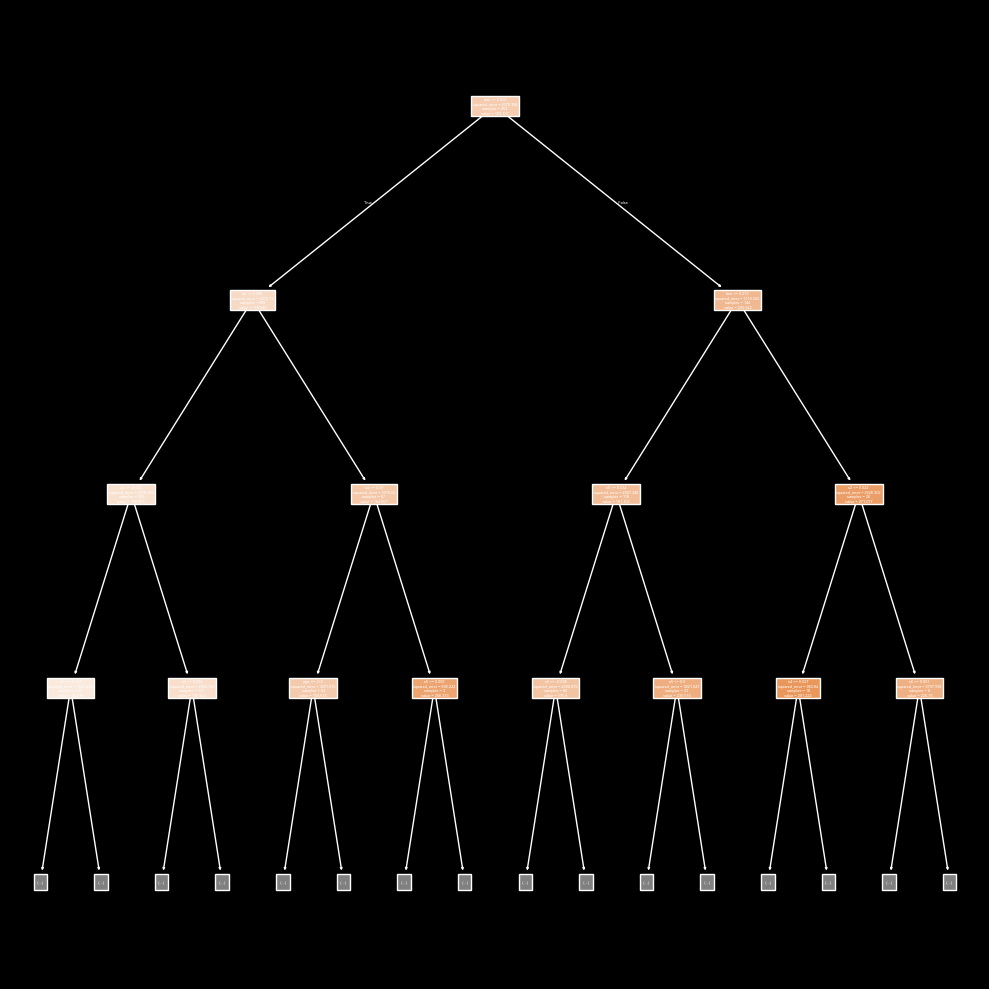

In [67]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    max_depth=3
)

plt.tight_layout()

In [68]:
# Support Vector Machine Classifier - SVC implementation

from sklearn.svm import SVC
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import datasets

df = datasets.load_iris(as_frame=True).frame

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [69]:
X = df.drop("target", axis=1)
y = df["target"]

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
#Model

svc = SVC()
svc.fit(X_train_scaled, y_train)

SVC()

In [72]:
y_pred = svc.predict(X_test_scaled)

In [73]:
# Evaluate

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy: ",accuracy_score(y_test, y_pred)*100)
print("Classification Report: ",classification_report(y_test, y_pred)*100)

Accuracy:  93.33333333333333
Classification Report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93 

In [74]:
# Linear kernel

svc = SVC(kernel='linear')
svc.fit(X_train_scaled, y_train)

y_pred = svc.predict(X_test_scaled)

print("Accuracy: ",accuracy_score(y_test, y_pred)*100)

Accuracy:  91.11111111111111


In [75]:
# Sigmoid kernel

svc = SVC(kernel='sigmoid')
svc.fit(X_train_scaled, y_train)
svc.fit(X_train_scaled, y_train)

y_pred = svc.predict(X_test_scaled)

print("Accuracy: ",accuracy_score(y_test, y_pred)*100)

Accuracy:  91.11111111111111


In [76]:
# Polynomial kernel

svc = SVC(kernel='poly')
svc.fit(X_train_scaled, y_train)

y_pred = svc.predict(X_test_scaled)

print("Accuracy: ",accuracy_score(y_test, y_pred)*100)

Accuracy:  86.66666666666667


In [77]:
# rbf kernel
C_vals = [0.5,1,2,3,4,5]

for c_val in C_vals:
    svc = SVC(kernel='linear')
    svc.fit(X_train_scaled, y_train)

    y_pred = svc.predict(X_test_scaled)

    print("C = ",c_val,"& Accuracy: ",accuracy_score(y_test, y_pred)*100)

C =  0.5 & Accuracy:  91.11111111111111
C =  1 & Accuracy:  91.11111111111111
C =  2 & Accuracy:  91.11111111111111
C =  3 & Accuracy:  91.11111111111111
C =  4 & Accuracy:  91.11111111111111
C =  5 & Accuracy:  91.11111111111111


In [78]:
# Support Vector Machine Regressor - SVR implementation

from sklearn.svm import SVR
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

df = datasets.load_diabetes(as_frame=True).frame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [79]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1)).ravel()

model = SVR()
model.fit(X_train, y_train_scaled)

SVR()

In [80]:
y_pred_scaled = model.predict(X_test)
y_train_pred_scaled = model.predict(X_train)

print("r2_score: ", r2_score(y_train, y_train_pred_scaled))
print("r2_score: ", r2_score(y_test, y_pred_scaled))

r2_score:  -3.875800642631062
r2_score:  -4.00597872046441


In [81]:
# Linear

model = SVR(kernel='linear')
model.fit(X_train, y_train_scaled)

y_train_pred_scaled = model.predict(X_train)
y_pred_scaled = model.predict(X_test)

print("r2_score: ", r2_score(y_train, y_train_pred_scaled))
print("r2_score: ", r2_score(y_test, y_pred_scaled))


r2_score:  -3.883993392729919
r2_score:  -4.01157792494357


In [82]:
# polynomial

model = SVR(kernel='poly')
model.fit(X_train, y_train_scaled)

y_train_pred_scaled = model.predict(X_train)
y_pred_scaled = model.predict(X_test)

print("r2_score: ", r2_score(y_train, y_train_pred_scaled))
print("r2_score: ", r2_score(y_test, y_pred_scaled))

r2_score:  -3.8777180970724077
r2_score:  -4.00807994075752


In [83]:
# Hyperparameter tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [1,2,5,10,50,100],
    "kernel": ["rbf", "linear", "poly", "sigmoid"],
    "epsilon": [0.01,0.1,0.2,0.3,0.5]
}

svr = SVR()

grid_search = GridSearchCV(svr, param_grid, scoring='r2', cv=5)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 2, 5, 10, 50, 100],
                         'epsilon': [0.01, 0.1, 0.2, 0.3, 0.5],
                         'kernel': ['rbf', 'linear', 'poly', 'sigmoid']},
             scoring='r2')

In [84]:
print("best params - ",grid_search.best_params_)

best params -  {'C': 10, 'epsilon': 0.1, 'kernel': 'sigmoid'}


In [85]:
best_model = SVR(kernel='linear', C=10, epsilon=0.1)

model.fit(X_train, y_train_scaled)

y_train_pred_scaled = model.predict(X_train)
y_pred_scaled = model.predict(X_test)

print("r2_score: ", r2_score(y_train, y_train_pred_scaled))
print("r2_score: ", r2_score(y_test, y_pred_scaled))

r2_score:  -3.8777180970724077
r2_score:  -4.00807994075752


In [86]:
from sklearn.svm import LinearSVR

model = LinearSVR(C=10, epsilon=0.1, max_iter=5000)
model.fit(X_train, y_train_scaled)

y_train_pred_scaled = model.predict(X_train)
y_pred_scaled = model.predict(X_test)

print("r2_score: ", r2_score(y_train, y_train_pred_scaled))
print("r2_score: ", r2_score(y_test, y_pred_scaled))

r2_score:  -3.8784525212758734
r2_score:  -4.009078899999697


In [87]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=201,
    oob_score=True,
    bootstrap=True,
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score_)
print("Testing Accuracy: ",accuracy_score(y_test, y_pred))

OOB score:  0.014164305949008499
Testing Accuracy:  0.0


In [88]:
# Bagging Classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred)*100)

Accuracy:  0.0


In [89]:
# Gradient Boosting for Regression

from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=1000,
    n_features=10,
    noise=20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)


In [90]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42,
                          subsample=0.8)

In [91]:
y_pred = gbr.predict(X_test)

print("R2: ",r2_score(y_test, y_pred))

R2:  0.9178283453526048


In [92]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=150,
    max_depth=3,
    random_state=42
)

gbc.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=150, random_state=42)

In [93]:
y_pred = gbc.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred))

Accuracy:  0.925


In [94]:
#AdaBoosdt Classifier

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42
)

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# DT stump

base_model = DecisionTreeClassifier(
    max_depth=1
)


# adaboost classifier
from sklearn.ensemble import AdaBoostClassifier

abc = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100,
    random_state=42
)

abc.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

In [95]:
y_pred = abc.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred))
print("Classification Report: ",classification_report(y_test, y_pred))


Accuracy:  0.82
Classification Report:                precision    recall  f1-score   support

           0       0.81      0.87      0.84        53
           1       0.84      0.77      0.80        47

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



In [96]:
#AdaBoosdt Regressor

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

X, y = make_regression(
    n_samples=500,
    n_features=20,
    n_informative=10,
    random_state=42
)

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# DT stump

base_model = DecisionTreeRegressor()


# adaboost classifier
from sklearn.ensemble import AdaBoostRegressor

abc = AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    random_state=42
)

abc.fit(X_train, y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(), n_estimators=100,
                  random_state=42)

In [97]:
y_pred = abc.predict(X_test)

print("MSE: ",mean_squared_error(y_test, y_pred)*100)
print("MAE: ",mean_absolute_error(y_test, y_pred)*100)


MSE:  344283.06886119343
MAE:  4650.65871487132


In [98]:
# XGBoost

import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [99]:
y_pred = xgb_clf.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred)*100)
print("Classification Report: ",classification_report(y_test, y_pred)*100)

Accuracy:  89.0
Classification Report:                precision    recall  f1-score   support

           0       0.89      0.91      0.90        53
           1       0.89      0.87      0.88        47

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        53
           1       0.89      0.87      0.88        47

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        53
           1       0.89      0.87      0.88        47

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89   

In [100]:
# Voting classifier

from sklearn.ensemble import VotingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression()
svc = SVC()
dtc = DecisionTreeClassifier()

voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('svc', svc),
        ('dtc', dtc),
    ]
)


voting_clf.fit(X_train, y_train)


VotingClassifier(estimators=[('lr', LogisticRegression()), ('svc', SVC()),
                             ('dtc', DecisionTreeClassifier())])

In [101]:
y_pred = voting_clf.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred))
print("Classification Report: ",classification_report(y_test, y_pred))

Accuracy:  0.86
Classification Report:                precision    recall  f1-score   support

           0       0.90      0.84      0.87        56
           1       0.81      0.89      0.85        44

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100



In [102]:
# Voting REgression

from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=500,
    n_features=20,
    n_informative=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

lin_reg = LinearRegression()
dtr = DecisionTreeRegressor()
svr = SVR()

from sklearn.ensemble import VotingRegressor

vr = VotingRegressor(
    estimators=[
        ('lin_reg', lin_reg),
        ('svr', svr),
        ('dtr', dtr)
    ]
)

vr.fit(X_train, y_train)

VotingRegressor(estimators=[('lin_reg', LinearRegression()), ('svr', SVR()),
                            ('dtr', DecisionTreeRegressor())])

In [103]:
y_pred = vr.predict(X_test)

from sklearn.metrics import r2_score

print("R2: ",r2_score(y_test, y_pred))

R2:  0.842233968810055


In [104]:
#Stacking classifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=5,
    random_state=42
)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import StackingClassifier

meta_model = LogisticRegression()

stacking_clf = StackingClassifier(
    estimators=[
        ('lr',lr),
        ('svc',svc),
        ('dtc',dtc)
    ],
    final_estimator=meta_model,
    cv=5
)

stacking_clf.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression()), ('svc', SVC()),
                               ('dtc', DecisionTreeClassifier())],
                   final_estimator=LogisticRegression())

In [105]:
y_pred = stacking_clf.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred))

Accuracy:  0.88


In [106]:
# Stacking Regressor
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=500,
    n_features=20,
    n_informative=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import StackingRegressor

sr = StackingRegressor(
    estimators=[
        ('lr', lin_reg),
        ('svr', svr),
        ('dtr', dtr)
    ],
    cv=5
)

sr.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('lr', LinearRegression()), ('svr', SVR()),
                              ('dtr', DecisionTreeRegressor())])

In [107]:
y_pred = sr.predict(X_test)
y_pred_train = sr.predict(X_train)

print("R2: ",r2_score(y_test, y_pred))
print("R2: ",r2_score(y_train, y_pred_train))

R2:  0.9999999999999816
R2:  0.9999999999999972
